part2:

function: $\int_{0}^\infty x^{-(1/2)}*J_1(2x)$

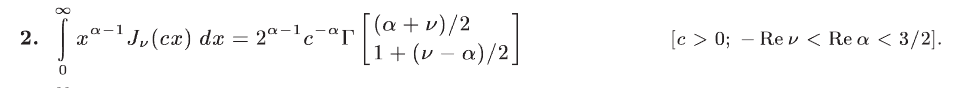

ans = $2^{-1/2}*2^{-1/2}*Г((1/2+1)/2)/Г(1+(1/2)/2)$ = $2^{-1}*Г(3/4)/Г(5/4)$


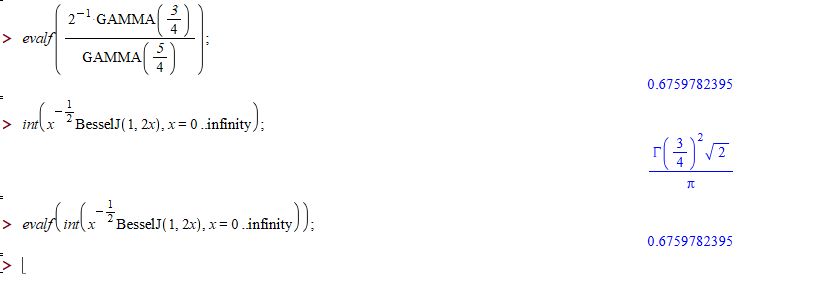

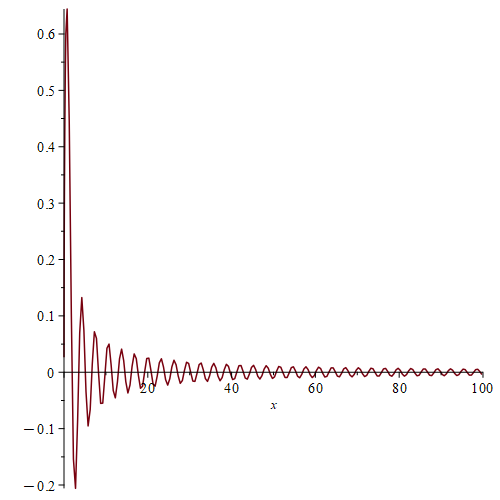

In [1]:
import numpy as np
from scipy import special
from matplotlib import pyplot as plt

In [5]:
a = 1e-5
b = 1e6

f = lambda x: x**(-1/2)*special.j1(2*x)
exact_val = 0.6767568759
# f = lambda x: special.j1(x)*special.y0(2*x)
# exact_val = 0.09157204773

def l_rectangle(f,N):
    x = np.linspace(a,b,N+1)
    y = f(x)
    h = (x[1] - x[0])
    res = h*np.sum(y[0:-1])
    return res

def r_rectangle(f,N):
    x = np.linspace(a,b,N+1)
    y = f(x)
    h = (x[1] - x[0])
    res = h*np.sum(y[1::])
    return res

def c_rectangle(f,N):
    x = np.linspace(a,b,N+1)
    h = (x[1] - x[0])
    y = f(x + h/2)
    return h*np.sum(y[0:-1:])

def trapezoid(f,N):
    x = np.linspace(a,b,N+1)
    h = (x[1] - x[0])
    y = f(x)
    return h*((y[0] + y[-1])/2 + np.sum(y[1:-1:]))

def simpson(f,N):
    if N%2==1:
        N+=1
    x = np.linspace(a,b,N+1)
    h = (x[1] - x[0])
    y = f(x)
    
    weights = np.ones(N + 1)
    weights[1:N:2] = 4
    weights[2:N-1:2] = 2
    
    return (h / 3) * np.sum(weights * y)


In [6]:
N = 10000000
print(f"Левые прямоугольники err: {np.abs(l_rectangle(f, N) - exact_val)}")
print(f"Правые прямоугольники err: {np.abs(r_rectangle(f, N) - exact_val)}")
print(f"Средние прямоугольники err : {np.abs(c_rectangle(f, N) - exact_val)}")
print(f"Трапеции err : {np.abs(trapezoid(f, N) - exact_val)}")
print(f"Симпсон err : {np.abs(simpson(f, N) - exact_val)}")

Левые прямоугольники err: 0.007039994896029134
Правые прямоугольники err: 0.007356278941745953
Средние прямоугольники err : 0.0011469587717123364
Трапеции err : 0.0071981369188866
Симпсон err : 0.0032392261681086776


[16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576, 2097152]
[197.39000230069777, 98.58414342166296, 48.8827115136546, 23.731350309388475, 12.060485006791637, 5.443571183927786, 1.9363522626760143, 1.2269729855644051, 0.009045908394897384, 0.7915787763476063, 0.12791611084890275, 0.67288031686878, 1.1351039753796335, 0.3009669279861535, 0.1990542928288901, 0.5955996099785398, 0.19519852605603827, 0.06805006888436416] [0.287526273450991, 0.2546208654114356, 0.5366706298825907, 0.9783407623801139, 0.2943605290926606, 0.7338515840143636, 1.1523591212950601, 0.3173827064211319, 0.7631319375978715, 1.1776676993439905, 0.3209605723470949, 0.7694025476178762, 1.1833650907541817, 0.32509748567342744, 0.2111195716725266, 0.6016322494003582, 0.19821484576694737, 0.06955822873981854] [0.22171545735505394, 0.8187203943428285, 1.4200108948819996, 0.3896197041947407, 1.1733426389344057, 1.5708666585739035, 0.5175937084532856, 1.2088811687749046, 

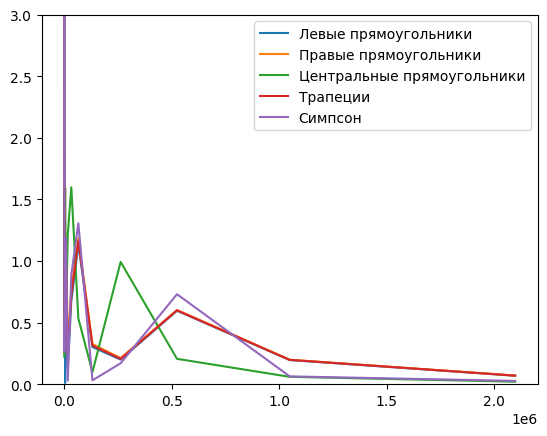

In [7]:
N_list = [2**i for i in range(4,22)]
print(N_list)
left_errs = []
right_errs = []
center_errs = []
trapz_errs = []
simpson_errs = []

for N in N_list:
    left_errs.append(np.abs(l_rectangle(f, N) - exact_val))
    right_errs.append(np.abs(r_rectangle(f, N) - exact_val))
    center_errs.append(np.abs(c_rectangle(f, N) - exact_val))
    trapz_errs.append(np.abs(trapezoid(f, N) - exact_val))
    simpson_errs.append(np.abs(simpson(f, N) - exact_val))
print(left_errs,right_errs,center_errs)
ax = plt.gca()
ax.set_ylim([0,3])
plt.plot(N_list[1::],left_errs[1::],label="Левые прямоугольники")
plt.plot(N_list,right_errs,label="Правые прямоугольники")
plt.plot(N_list,center_errs,label="Центральные прямоугольники")
plt.plot(N_list,trapz_errs,label="Трапеции")
plt.plot(N_list,simpson_errs,label="Симпсон")
plt.legend()